## Introduction


Since some features in the more pre-trained or fine-tuned concept model are correlated to patient CPI response status, among the 45 pre-trained features, we found that the following features are highly correlated features, such as `CD8_Tcell`,`CD4_Tcell`, `Cytotoxic_Tcell`,`Exhausted_Tcell`, `Macrophage`, `NKcell`, `TMB`, `PLFcell`, `Memory_Tcell`, `IFNg_pathway`, `Monocyte`, `Myeloid`, etc.

---
In this example, we demonstrate how to extract features based on pretrainer or finetuner for building a logistic regression model

In [1]:

from compass.utils import plot_embed_with_label
from compass import PreTrainer, FineTuner, loadcompass #, get_minmal_epoch
from compass.utils import plot_embed_with_label, plot_performance, score2
from compass.tokenizer import CANCER_CODE
import os
from tqdm import tqdm
from itertools import chain
import pandas as pd
import numpy as np
import random, torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = 'white', font_scale=1.3)
import warnings
warnings.filterwarnings("ignore")

def onehot(S):
    assert type(S) == pd.Series, 'Input type should be pd.Series'
    dfd = pd.get_dummies(S, dummy_na=True)
    nanidx = dfd[dfd[np.nan].astype(bool)].index
    dfd.loc[nanidx, :] = np.nan
    dfd = dfd.drop(columns=[np.nan])*1.
    cols = dfd.sum().sort_values(ascending=False).index.tolist()
    dfd = dfd[cols]
    return dfd

## Extract the features to be used in a LGR model

In [2]:
## load model
model = loadcompass('https://www.immuno-compass.com/download/model/pretrainer.pt')

## read data
df_label = pd.read_pickle('./tmpignore/ITRP.PATIENT.TABLE')
df_tpm = pd.read_pickle('./tmpignore/ITRP.TPM.TABLE')

df_label = df_label[df_label.cohort == 'IMmotion150']
df_tpm = df_tpm.loc[df_label.index]
dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
df_task = onehot(df_label.loc[dfcx.index].response_label)

dfcx.head()

,cancer_code,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Index,,,,,,,,,,,,,,,,,,,,,
IMmotion150-p01155-ar-28f34,11,0.000000,0.098867,569.650898,0.000000,12.308948,0.018497,63.707358,14.434985,66.125180,...,6.389789,5.303300,5.051903,4.589033,10.261535,0.288717,25.858985,56.947976,42.042863,10.116892
IMmotion150-p03058-ar-c2dad,11,0.254285,12.912481,2219.543961,0.130203,17.130387,0.164449,63.061299,9.498081,1.242164,...,11.407857,1.783814,4.070043,3.850006,7.302152,1.027050,26.337602,70.748166,47.674605,11.859255
IMmotion150-p03363-ar-a74ac,11,1.738725,21.307989,2022.470916,0.000000,39.377504,0.000000,102.279939,8.651851,0.000000,...,5.026485,3.233093,6.573876,4.301948,11.420510,0.136894,20.903173,66.970426,42.152788,5.789718
IMmotion150-p03418-ar-d867a,11,256.478618,78.939864,1504.517253,0.008377,14.008435,0.000000,85.648168,8.166077,63.876737,...,7.095447,7.343206,4.634568,5.377463,13.105987,0.545127,18.968981,46.839687,36.639318,9.111185
IMmotion150-p03665-ar-04d83,11,2.428848,1.952094,945.986656,0.000000,10.977868,0.112258,75.503642,15.587454,0.208317,...,9.394811,5.791613,5.701962,5.184023,9.787591,0.146017,17.989702,100.555068,47.372759,7.922010


In [3]:
## Extract the features, including geneset features and celltype features
dfg, dfc = model.extract(dfcx, batch_size = 16)

100%|##########| 11/11 [00:02<00:00,  5.19it/s]


In [4]:
## all of the 45 borader features
print(dfc.columns)

Index(['CANCER', 'Adipocyte', 'Apoptosis_pathway', 'Bcell', 'CD4_Tcell',
       'CD8_Tcell', 'CPI_Response', 'CPI_effect', 'Cytokine_chemokine',
       'Cytotoxic_Tcell', 'Endothelial', 'Epithelial', 'Erythrocyte',
       'Exhausted_Tcell', 'Fibroblast', 'Granulocyte', 'Hepatocyte',
       'IFNg_pathway', 'Immune_checkpoint', 'Immune_score',
       'Innate_lymphoid_cell', 'Macrophage', 'Mast', 'Memory_Tcell',
       'Mesothelial', 'Monocyte', 'Myeloid', 'NKcell', 'Naive_Tcell',
       'Neutrophil', 'OS_effect', 'PLFcell', 'Pancreatic', 'Platelet',
       'Pneumocyte', 'Stem', 'Stroma', 'TGFb_pathway', 'TLS', 'TMB',
       'Tcell_exclusion', 'Tcell_general', 'Treg', 'cDC', 'pDC', 'Reference'],
      dtype='object')


In [5]:
selected_features =  ['CD8_Tcell', 'CD4_Tcell', 'Cytotoxic_Tcell', 
                      'Exhausted_Tcell', 'Macrophage', 'NKcell', 'TMB', 'CPI_effect',
                      'PLFcell', 'Memory_Tcell', 'Monocyte', 'Myeloid' ]

## Build a LGR model

In [6]:

from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [7]:
cohort_dfx = dfc[selected_features]
cohort_dfy = df_task['R']

# split train, test
test_idx = df_label.groupby('response_label').sample(frac=0.2, random_state=42).index
train_idx = df_label.index.difference(test_idx)

train_X = cohort_dfx.loc[train_idx]
train_y = cohort_dfy.loc[train_idx]
test_X = cohort_dfx.loc[test_idx]    
test_y = cohort_dfy.loc[test_idx]

print(len(train_idx), len(test_idx))

132 33


In [8]:
param_grid = {'penalty':['l2'], 'max_iter':[int(1e10)], 'solver':['lbfgs'],
              'C':np.arange(0.1, 10, 0.1), 'class_weight':['balanced'] }

lgr_model = LogisticRegression()
gcv = GridSearchCV(lgr_model, param_grid=param_grid, 
                   scoring='roc_auc', cv=5, n_jobs=-1).fit(train_X, train_y)

## Make prediction based on the best model

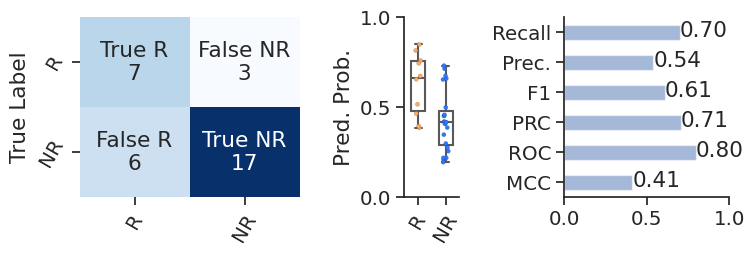

In [9]:
pred_prob = gcv.best_estimator_.predict_proba(test_X)
pred_testy = pd.DataFrame(pred_prob, index = test_X.index)
y_true = test_y
y_prob = pred_testy[1]
y_pred = pred_testy.idxmax(axis=1)

fig = plot_performance(y_true, y_prob, y_pred)

## Discussions

In this example, we show how to build a LGR model based on the conceptor features. In practical, you can also extract the features from a finetuned model insead of the pretrained model